# Laboratorio 10 - Paso 1: selección y análisis del dataset Mushrooms

**Curso:** CC3074 Minería de Datos  
**Tema:** Aprendizaje semi-supervisado  
**Fuente del dataset:** Kaggle, *Mushroom Classification* (`uciml/mushroom-classification`)  
**Archivo usado:** `mushrooms.csv`

Este notebook cubre el **Paso 1** del laboratorio: selección del dataset, exploración, limpieza y preprocesamiento. Todavía no entrena modelos; deja la matriz lista para usar después en el escenario semi-supervisado.

## 1. Objetivo del análisis

El laboratorio pide un dataset real con al menos 1000 filas y 8 columnas. El dataset de hongos cumple esa condición porque contiene más de 8000 observaciones y más de 20 atributos categóricos. La variable objetivo indica si cada hongo es **venenoso** (`p`) o **comestible** (`e`).

En este paso se revisa:

- dimensión del dataset;
- tipos de variables;
- valores faltantes o codificados como `?`;
- balance de clases;
- distribución de categorías;
- asociación de cada variable con la clase;
- transformación final para dejar los datos listos para algoritmos de clasificación.

In [1]:
# Setup reproducible
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.stats import chi2_contingency
from sklearn.preprocessing import OneHotEncoder

SEED = 42
DATA_PATH = Path("mushrooms.csv")

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.3f}".format)

print(f"Archivo encontrado: {DATA_PATH.exists()} -> {DATA_PATH.resolve()}")

Archivo encontrado: True -> /Users/yehosuahercules/Desktop/MineriaDatos/Laboratorio10Mineria/mushrooms.csv


## 2. Carga e inspección inicial

In [2]:
df = pd.read_csv(DATA_PATH)

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")
display(df.head())

Filas: 8,124
Columnas: 23


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,e,e,s,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,e,c,s,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,e,c,s,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,e,e,s,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,t,e,s,s,w,w,p,w,o,e,n,a,g


In [3]:
summary = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "n_unicos": df.nunique(),
    "faltantes_nan": df.isna().sum(),
    "conteo_signo_pregunta": (df == "?").sum(),
})
summary["porcentaje_signo_pregunta"] = (summary["conteo_signo_pregunta"] / len(df) * 100).round(2)
display(summary)

,tipo,n_unicos,faltantes_nan,conteo_signo_pregunta,porcentaje_signo_pregunta
class,str,2,0,0,0.000
cap-shape,str,6,0,0,0.000
cap-surface,str,4,0,0,0.000
cap-color,str,10,0,0,0.000
bruises,str,2,0,0,0.000
odor,str,9,0,0,0.000
gill-attachment,str,2,0,0,0.000
gill-spacing,str,2,0,0,0.000
gill-size,str,2,0,0,0.000
gill-color,str,12,0,0,0.000


Todas las columnas vienen como variables categóricas. El dataset no trae `NaN`, pero sí usa el símbolo `?` como valor desconocido en algunas columnas. En este caso se trata como categoría **desconocido** para no perder muchas filas.

In [4]:
duplicate_rows = df.duplicated().sum()
class_map = {"e": "Comestible", "p": "Venenoso"}
class_counts = df["class"].map(class_map).value_counts().rename_axis("clase").reset_index(name="conteo")
class_counts["porcentaje"] = (class_counts["conteo"] / len(df) * 100).round(2)

print(f"Filas duplicadas exactas: {duplicate_rows:,}")
display(class_counts)

Filas duplicadas exactas: 0


,clase,conteo,porcentaje
0,Comestible,4208,51.800
1,Venenoso,3916,48.200


## 3. Balance de clases

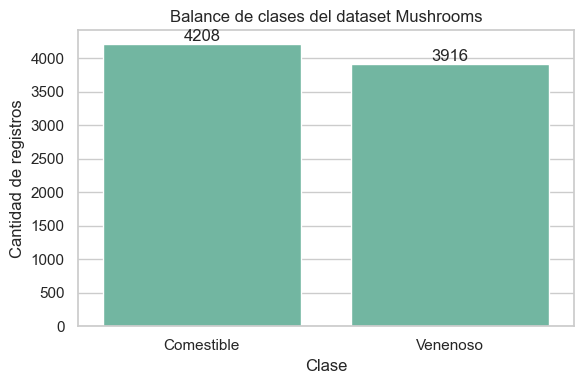

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=class_counts, x="clase", y="conteo", ax=ax)
ax.set_title("Balance de clases del dataset Mushrooms")
ax.set_xlabel("Clase")
ax.set_ylabel("Cantidad de registros")
for container in ax.containers:
    ax.bar_label(container, fmt="%d")
plt.tight_layout()
plt.show()

El dataset está bastante balanceado entre hongos comestibles y venenosos. Esto ayuda para los pasos posteriores porque las métricas no van a estar dominadas por una sola clase.

## 4. Revisión de valores desconocidos

,conteo_desconocido,porcentaje
stalk-root,2480,30.530


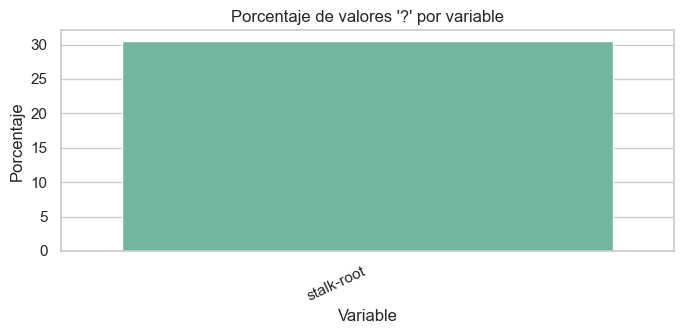

In [6]:
unknown_counts = (df == "?").sum()
unknown_counts = unknown_counts[unknown_counts > 0].sort_values(ascending=False)
unknown_table = unknown_counts.rename("conteo_desconocido").to_frame()
unknown_table["porcentaje"] = (unknown_table["conteo_desconocido"] / len(df) * 100).round(2)
display(unknown_table)

fig, ax = plt.subplots(figsize=(7, 3.5))
if len(unknown_table):
    sns.barplot(x=unknown_table.index, y=unknown_table["porcentaje"], ax=ax)
    ax.set_title("Porcentaje de valores '?' por variable")
    ax.set_xlabel("Variable")
    ax.set_ylabel("Porcentaje")
    plt.xticks(rotation=25, ha="right")
else:
    ax.text(0.5, 0.5, "No hay valores '?'", ha="center", va="center")
    ax.axis("off")
plt.tight_layout()
plt.show()

La columna `stalk-root` concentra los valores `?`. Como representa cerca de un tercio de los registros, eliminar esas filas sería una pérdida fuerte de información. Por eso se reemplaza `?` por la categoría `desconocido`.

## 5. Cardinalidad y distribución de variables categóricas

,n_categorias
gill-color,12
cap-color,10
odor,9
spore-print-color,9
stalk-color-below-ring,9
stalk-color-above-ring,9
habitat,7
population,6
cap-shape,6
stalk-root,5


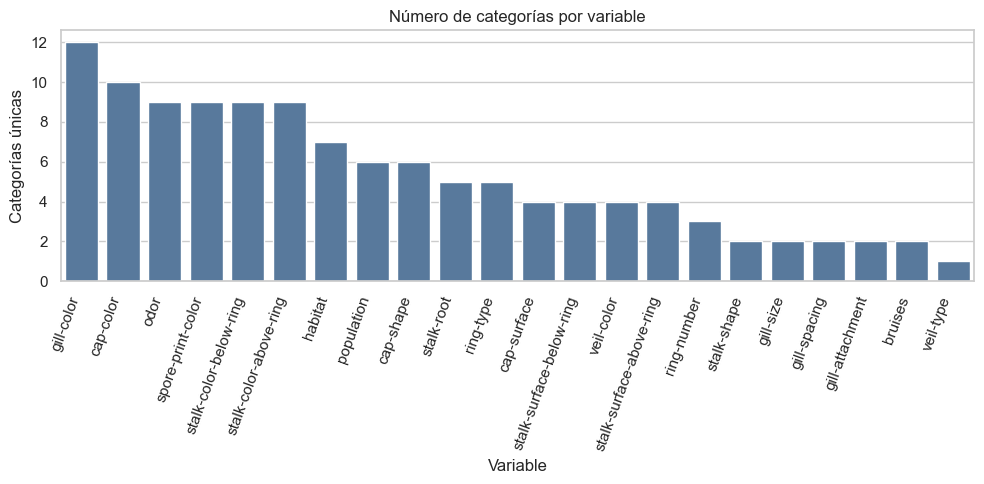

In [7]:
feature_cols = [col for col in df.columns if col != "class"]
cardinality = df[feature_cols].nunique().sort_values(ascending=False).rename("n_categorias").to_frame()
display(cardinality)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=cardinality.index, y=cardinality["n_categorias"], ax=ax, color="#4C78A8")
ax.set_title("Número de categorías por variable")
ax.set_xlabel("Variable")
ax.set_ylabel("Categorías únicas")
plt.xticks(rotation=70, ha="right")
plt.tight_layout()
plt.show()

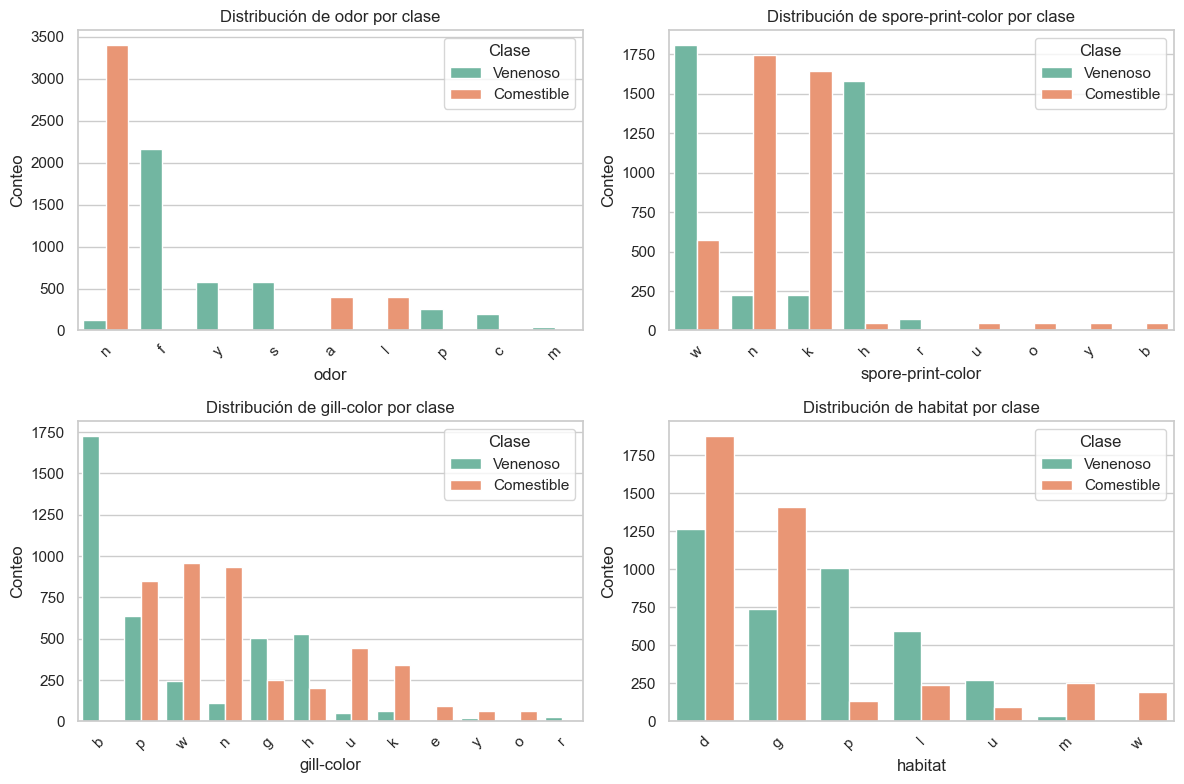

In [8]:
selected_features = ["odor", "spore-print-color", "gill-color", "habitat"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
for ax, feature in zip(axes, selected_features):
    temp = df.copy()
    temp["class_name"] = temp["class"].map(class_map)
    order = temp[feature].value_counts().index
    sns.countplot(data=temp, x=feature, hue="class_name", order=order, ax=ax)
    ax.set_title(f"Distribución de {feature} por clase")
    ax.set_xlabel(feature)
    ax.set_ylabel("Conteo")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(title="Clase")
plt.tight_layout()
plt.show()

Algunas variables muestran separación fuerte entre clases. `odor` es especialmente informativa: ciertas categorías aparecen casi solo en hongos venenosos o comestibles.

## 6. Asociación entre variables y clase

Como las variables son categóricas, uso V de Cramér para medir la fuerza de asociación entre cada predictor y la clase. Valores cercanos a 0 indican asociación débil; valores cercanos a 1 indican asociación fuerte.

,variable,v_cramer
4,odor,0.971
19,spore-print-color,0.753
8,gill-color,0.681
18,ring-type,0.603
11,stalk-surface-above-ring,0.588
12,stalk-surface-below-ring,0.575
7,gill-size,0.540
13,stalk-color-above-ring,0.525
14,stalk-color-below-ring,0.515
3,bruises,0.502


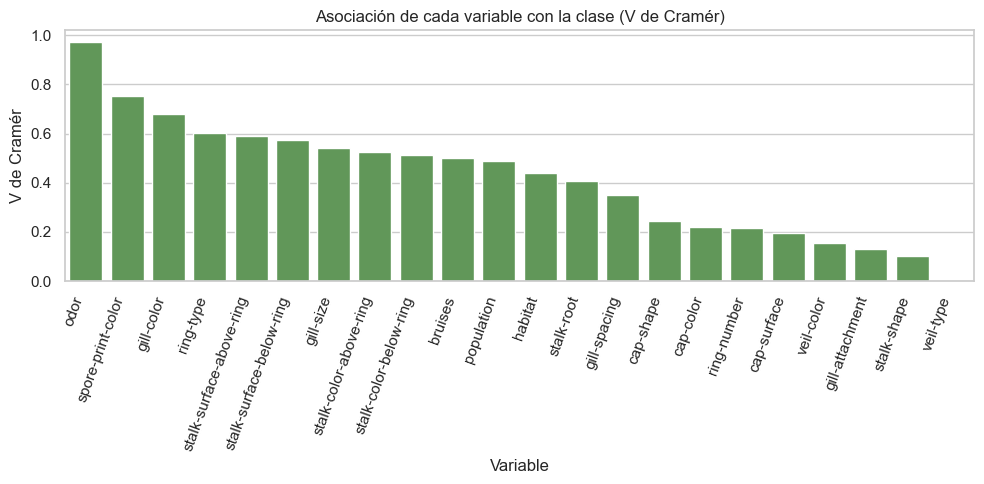

In [9]:
def cramers_v(x: pd.Series, y: pd.Series) -> float:
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table, correction=False)[0]
    n = table.to_numpy().sum()
    if n == 0:
        return np.nan
    phi2 = chi2 / n
    r, k = table.shape
    return np.sqrt(phi2 / max(1, min(k - 1, r - 1)))

association = pd.DataFrame({
    "variable": feature_cols,
    "v_cramer": [cramers_v(df[col], df["class"]) for col in feature_cols],
}).sort_values("v_cramer", ascending=False)

display(association)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=association, x="variable", y="v_cramer", ax=ax, color="#59A14F")
ax.set_title("Asociación de cada variable con la clase (V de Cramér)")
ax.set_xlabel("Variable")
ax.set_ylabel("V de Cramér")
plt.xticks(rotation=70, ha="right")
plt.tight_layout()
plt.show()

## 7. Limpieza y preprocesamiento

Decisiones aplicadas:

1. Reemplazar `?` por `desconocido` para conservar registros.
2. Separar `class` como variable objetivo.
3. Codificar la clase: `p` = 1, `e` = 0.
4. Aplicar One-Hot Encoding a todas las variables predictoras porque los algoritmos numéricos no trabajan directamente con letras/categorías.
5. No se aplica normalización porque las columnas finales son binarias. Para modelos basados en distancia o margen, la matriz codificada puede escalarse después si el algoritmo lo requiere.

In [10]:
df_clean = df.replace("?", "desconocido").copy()
y = df_clean["class"].map({"e": 0, "p": 1}).astype(int)
X_raw = df_clean.drop(columns="class")

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.int8)
X_encoded_array = encoder.fit_transform(X_raw)
encoded_columns = encoder.get_feature_names_out(X_raw.columns)
X_encoded = pd.DataFrame(X_encoded_array, columns=encoded_columns, index=df_clean.index)

print(f"Matriz original X_raw: {X_raw.shape[0]:,} filas x {X_raw.shape[1]:,} columnas")
print(f"Matriz codificada X_encoded: {X_encoded.shape[0]:,} filas x {X_encoded.shape[1]:,} columnas")
print(f"Vector objetivo y: {y.shape[0]:,} registros")
display(X_encoded.head())

Matriz original X_raw: 8,124 filas x 22 columnas
Matriz codificada X_encoded: 8,124 filas x 117 columnas
Vector objetivo y: 8,124 registros


,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,cap-surface_y,cap-color_b,cap-color_c,cap-color_e,cap-color_g,cap-color_n,cap-color_p,cap-color_r,cap-color_u,cap-color_w,cap-color_y,...,spore-print-color_k,spore-print-color_n,spore-print-color_o,spore-print-color_r,spore-print-color_u,spore-print-color_w,spore-print-color_y,population_a,population_c,population_n,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0
2,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,...,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0
3,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
4,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0


In [11]:
preprocessing_summary = pd.DataFrame({
    "elemento": [
        "filas_finales",
        "columnas_originales_predictoras",
        "columnas_codificadas",
        "clases",
        "valores_desconocidos_reemplazados",
    ],
    "valor": [
        len(df_clean),
        X_raw.shape[1],
        X_encoded.shape[1],
        "0 = comestible, 1 = venenoso",
        int((df == "?").sum().sum()),
    ],
})
display(preprocessing_summary)

,elemento,valor
0,filas_finales,8124
1,columnas_originales_predictoras,22
2,columnas_codificadas,117
3,clases,"0 = comestible, 1 = venenoso"
4,valores_desconocidos_reemplazados,2480


## 8. Conclusión del Paso 1

El dataset seleccionado cumple los requisitos del laboratorio: es real, supera las 1000 filas y tiene más de 8 columnas. Todas las variables son categóricas, por lo que el preprocesamiento principal fue tratar valores desconocidos y aplicar One-Hot Encoding. El balance de clases es adecuado para clasificación y varias variables tienen asociación fuerte con la clase, especialmente `odor`, `spore-print-color`, `gill-color` y `ring-type`.

Con esto queda preparada la matriz `X_encoded` y el vector `y` para el siguiente paso, donde se podrá simular el escenario semi-supervisado ocultando etiquetas y comparando modelos supervisados contra modelos semi-supervisados.